In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('../data/cancer_dataset.csv')

# Menampilkan informasi dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (569, 33)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst 

Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Proporsi:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


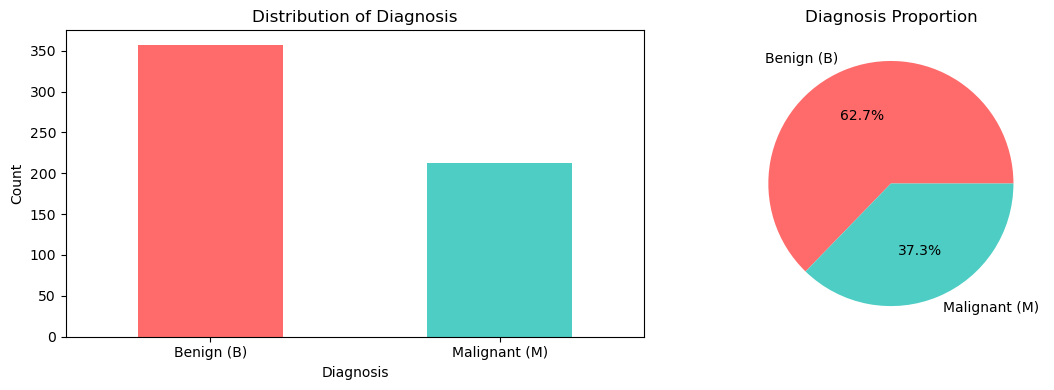

In [3]:
# Analisis diagnosis distribution
print("Diagnosis Distribution:")
print(df['diagnosis'].value_counts())
print("\nProporsi:")
print(df['diagnosis'].value_counts(normalize=True))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribution of Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Benign (B)', 'Malignant (M)'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                     colors=['#FF6B6B', '#4ECDC4'], labels=['Benign (B)', 'Malignant (M)'])
axes[1].set_title('Diagnosis Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [4]:
# Statistik deskriptif
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.01406

In [ ]:
# Persiapan data
df_clean = df.dropna(axis=1, how='all') 
df_clean = df_clean.drop(['id'], axis=1, errors='ignore')

if 'Unnamed: 32' in df_clean.columns:
    df_clean = df_clean.drop(['Unnamed: 32'], axis=1)

X = df_clean.drop(['diagnosis'], axis=1)
y = df_clean['diagnosis']

y = y.map({'M': 1, 'B': 0})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution after encoding:")
print(y.value_counts())

Features shape: (569, 30)
Target shape: (569,)

Target distribution after encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (455, 30)
Testing set shape: (114, 30)

Training target distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing target distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Model berhasil dilatih!")
print(f"Class priors: {nb_model.class_prior_}")
print(f"Classes: {nb_model.classes_}")

Model berhasil dilatih!
Class priors: [0.62637363 0.37362637]
Classes: [0 1]


In [ ]:
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"\nTraining Accuracy:  {train_accuracy:.4f}")
print(f"Testing Accuracy:   {test_accuracy:.4f}")
print(f"\nTraining Precision: {train_precision:.4f}")
print(f"Testing Precision:  {test_precision:.4f}")
print(f"\nTraining Recall:    {train_recall:.4f}")
print(f"Testing Recall:     {test_recall:.4f}")
print(f"\nTraining F1-Score:  {train_f1:.4f}")
print(f"Testing F1-Score:   {test_f1:.4f}")
print("="*60)

MODEL EVALUATION RESULTS

Training Accuracy:  0.9429
Testing Accuracy:   0.9386

Training Precision: 0.9444
Testing Precision:  1.0000

Training Recall:    0.9000
Testing Recall:     0.8333

Training F1-Score:  0.9217
Testing F1-Score:   0.9091


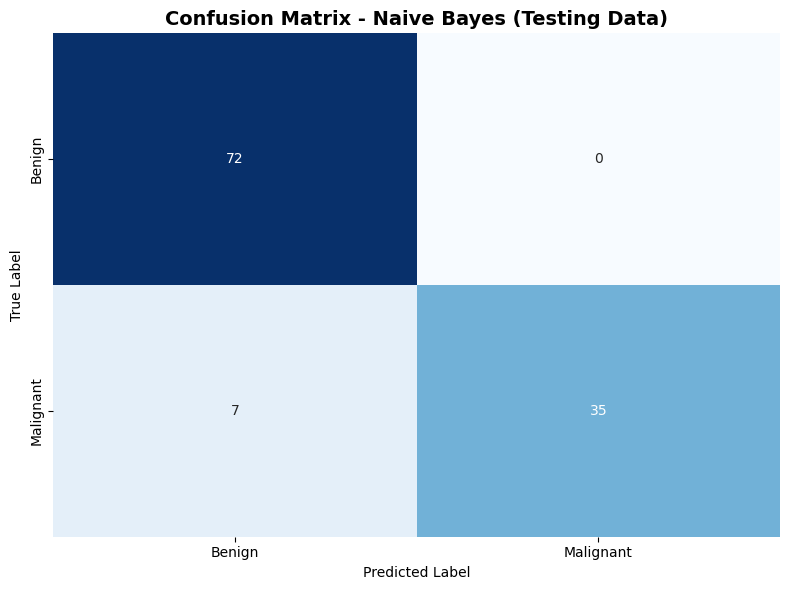


Confusion Matrix:
[[72  0]
 [ 7 35]]


In [12]:
# Confusion Matrix pada Testing Data
cm = confusion_matrix(y_test, y_test_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Naive Bayes (Testing Data)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

In [13]:
# Classification Report
print("\nClassification Report (Testing Data):")
print("="*60)
print(classification_report(y_test, y_test_pred, 
                          target_names=['Benign (0)', 'Malignant (1)']))


Classification Report (Testing Data):
               precision    recall  f1-score   support

   Benign (0)       0.91      1.00      0.95        72
Malignant (1)       1.00      0.83      0.91        42

     accuracy                           0.94       114
    macro avg       0.96      0.92      0.93       114
 weighted avg       0.94      0.94      0.94       114



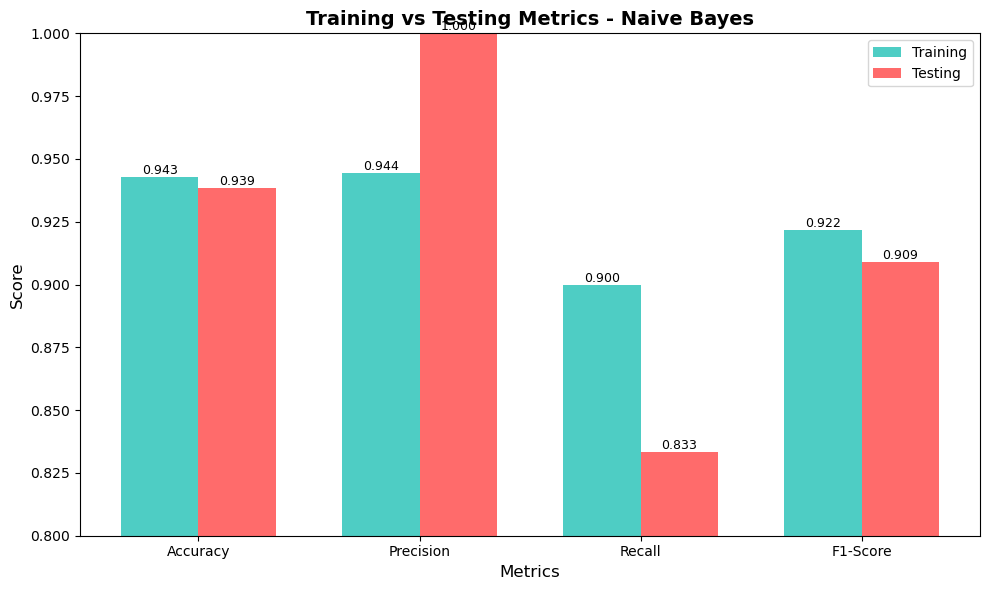

In [14]:
# Perbandingan metrik Train vs Test
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Training', color='#4ECDC4')
bars2 = ax.bar(x + width/2, test_scores, width, label='Testing', color='#FF6B6B')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Training vs Testing Metrics - Naive Bayes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0.8, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()